In [ ]:
!pip install torchsummary

In [ ]:
!pip install pytorch-lightning

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.0/823.0 kB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 49.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 28.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 18.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 85.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 960.9/960.9 kB 59.1 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-c

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.nn as nn
import numpy as np
import itertools
from sklearn.model_selection import train_test_split
import torch.optim as optim
from torchsummary import summary
import torch.optim as optim
import pytorch_lightning as pl
import wandb
from torchmetrics import Accuracy, F1Score, Precision, Recall
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

In [ ]:
class NeuralNetwork:
    def __init__(self, input_size, hidden1, hidden2, output_size):
        # Инициализация параметров
        self.W1 = np.random.randn(input_size, hidden1) * 0.01
        self.b1 = np.zeros((1, hidden1))
        self.W2 = np.random.randn(hidden1, hidden2) * 0.01
        self.b2 = np.zeros((1, hidden2))
        self.W3 = np.random.randn(hidden2, output_size) * 0.01
        self.b3 = np.zeros((1, output_size))

    def relu(self, x):
        return np.maximum(0, x)

    def relu_deriv(self, x):
        return x > 0

    def forward(self, X):
        # Прямое распространение
        self.z1 = np.dot(X, self.W1) + self.b1
        self.a1 = self.relu(self.z1)

        self.z2 = np.dot(self.a1, self.W2) + self.b2
        self.a2 = self.relu(self.z2)

        self.z3 = np.dot(self.a2, self.W3) + self.b3
        self.a3 = self.z3  # Линейная активация для регрессии
        return self.a3

    def backward(self, X, y, output, lr):
        # Обратное распространение
        m = X.shape[0]

        # Градиент выходного слоя
        delta3 = (output - y) / m
        dW3 = np.dot(self.a2.T, delta3)
        db3 = np.sum(delta3, axis=0, keepdims=True)

        # Градиент второго скрытого слоя
        delta2 = np.dot(delta3, self.W3.T) * self.relu_deriv(self.z2)
        dW2 = np.dot(self.a1.T, delta2)
        db2 = np.sum(delta2, axis=0, keepdims=True)

        # Градиент первого скрытого слоя
        delta1 = np.dot(delta2, self.W2.T) * self.relu_deriv(self.z1)
        dW1 = np.dot(X.T, delta1)
        db1 = np.sum(delta1, axis=0, keepdims=True)

        # Обновление параметров
        self.W3 -= lr * dW3
        self.b3 -= lr * db3
        self.W2 -= lr * dW2
        self.b2 -= lr * db2
        self.W1 -= lr * dW1
        self.b1 -= lr * db1

    def compute_loss(self, y, output):
        return np.mean((y - output) ** 2)

In [ ]:
class Trainer():
  def __init__(self, model,X,y,epochs, lr):
    self.model = model
    self.X = X
    self.y = y
    self.lr = lr
    self.epochs = epochs
    self.errors = []

  def train(self):
    for epoch in range(self.epochs):
      output = self.model.forward(self.X)
      self.model.backward(self.X, self.y, output, self.lr)
      loss = self.model.compute_loss(self.y, output)
      self.errors.append(loss)


In [ ]:
data = pd.read_csv('/content/sample_data/california_housing_test.csv')
data = data.dropna()

# Разделение на признаки (X) и целевую переменную (y)
X = data.drop('median_house_value', axis=1).values  # Признаки
y = data['median_house_value'].values.reshape(-1, 1)  # Целевая переменная

# Нормализация данных
scaler_X = StandardScaler()
scaler_y = StandardScaler()
X = scaler_X.fit_transform(X)
y = scaler_y.fit_transform(y)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
input_size = X_train.shape[1]  # Количество признаков
hidden1 = 100  # Количество нейронов в первом скрытом слое
hidden2 = 50  # Количество нейронов во втором скрытом слое
output_size = 1

nn = NeuralNetwork(input_size, hidden1, hidden2, output_size)
trainer = Trainer(nn, X_train, y_train, epochs=10000, lr = 0.01)
trainer.train()

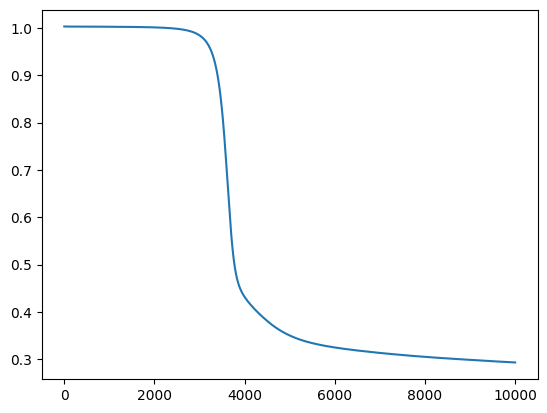

In [ ]:
plt.plot([i for i in range(10000)], trainer.errors)

In [ ]:
y_pred = nn.forward(X_test)
test_loss = nn.compute_loss(y_test, y_pred)
print(f"Test Loss: {test_loss:.4f}")

Test Loss: 0.2752


In [ ]:
y_pred_original = scaler_y.inverse_transform(y_pred)
y_test_original = scaler_y.inverse_transform(y_test)

# Пример вывода предсказаний и реальных значений
for i in range(15,20):
    print(f"Predicted: {y_pred_original[i][0]:.2f}, Actual: {y_test_original[i][0]:.2f}")

Predicted: 351037.37, Actual: 322500.00
Predicted: 93191.98, Actual: 67800.00
Predicted: 99739.08, Actual: 55400.00
Predicted: 417321.93, Actual: 500001.00
Predicted: 265041.00, Actual: 154800.00


# Часть 2
:

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])
dataset = datasets.CIFAR10(root="./data", train=True, transform=transform, download=True)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

100%|██████████| 170M/170M [00:03<00:00, 47.8MB/s]


In [ ]:
class MLP(pl.LightningModule):
    def __init__(self,
                 input_size=3072,
                 hidden_sizes=[1024, 512, 128, 64, 32],
                 num_classes=10,
                 lr=1e-3,
                 optimizer_cls=optim.Adam,
                 optimizer_params={},
                 batch_size=64,
                 dropout=0.5,
                 scheduler_params={'mode': 'min', 'factor': 0.1, 'patience': 3}):
        super().__init__()
        self.save_hyperparameters(ignore=['optimizer_params', 'scheduler_params'])
        self.optimizer_params = optimizer_params
        self.scheduler_params = scheduler_params

        layers = []
        prev_size = input_size
        for hidden_size in hidden_sizes:
                    layers.append(nn.Linear(prev_size, hidden_size))
                    layers.append(nn.BatchNorm1d(hidden_size))  # BatchNorm
                    layers.append(nn.ReLU())
                    layers.append(nn.Dropout(dropout))  # Dropout
                    prev_size = hidden_size
        layers.append(nn.Linear(prev_size, num_classes))
        self.model = nn.Sequential(*layers)

        self.criterion = nn.CrossEntropyLoss()
        self.accuracy = Accuracy(task="multiclass", num_classes=num_classes)
        self.f1 = F1Score(task="multiclass", num_classes=num_classes)
        self.precision = Precision(task="multiclass", num_classes=num_classes)
        self.recall = Recall(task="multiclass", num_classes=num_classes)

    def forward(self, x):
        return self.model(x.view(x.size(0), -1))

    def compute_metrics(self, logits, targets):
        loss = self.criterion(logits, targets)
        return {
            "loss": loss,
            "acc": self.accuracy(logits, targets),
            "f1": self.f1(logits, targets),
            "precision": self.precision(logits, targets),
            "recall": self.recall(logits, targets)
        }

    def training_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        metrics = self.compute_metrics(logits, y)
        self.log_dict(
            {f"train_{k}": v for k, v in metrics.items()},
            on_step=False,  # Отключаем логирование шагов
            on_epoch=True,  # Логируем только эпохи
            prog_bar=True,
            sync_dist=True
        )
        return metrics["loss"]

    def validation_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        metrics = self.compute_metrics(logits, y)
        self.log_dict(
            {f"val_{k}": v for k, v in metrics.items()},
            on_step=False,
            on_epoch=True,
            prog_bar=True,
            sync_dist=True
        )
        return metrics["loss"]

    def configure_optimizers(self):
        optimizer = self.hparams.optimizer_cls(self.parameters(), lr=self.hparams.lr, **self.optimizer_params)
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, **self.scheduler_params)
        return {"optimizer": optimizer, "lr_scheduler": {"scheduler": scheduler, "monitor": "val_loss"}}

In [ ]:
def train_experiment(lr, optimizer_cls, optimizer_params, batch_size):
    wandb.init(
        project="CIFAR_10",
        group=f"opt_{optimizer_cls.__name__}",
        name=f"lr_{lr}_bs_{batch_size}",
        config={
            "lr": lr,
            "optimizer": optimizer_cls.__name__,
            "optimizer_params": optimizer_params,
            "batch_size": batch_size
        }
    )

    model = MLP(
        lr=lr,
        optimizer_cls=optimizer_cls,
        optimizer_params=optimizer_params,
        batch_size=batch_size,
        hidden_sizes=[1024, 512, 128, 64, 32],
        dropout=0.3
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=4,
        pin_memory=True,
        persistent_workers=True
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=4,
        pin_memory=True,
        persistent_workers=True
    )

    wandb_logger = pl.loggers.WandbLogger(
        log_every_n_steps=0
        )

    trainer = pl.Trainer(
        max_epochs=15,
        logger=wandb_logger,
        accelerator="auto",
        devices=1,
        callbacks=[
            pl.callbacks.EarlyStopping(
                monitor="val_loss",
                patience=5,
                mode="min"
            )
        ],
        gradient_clip_val=1.0,
        enable_progress_bar=True,
        check_val_every_n_epoch=1,
    )

    try:
        trainer.fit(model, train_loader, val_loader)
    except Exception as e:
        print(f"Ошибка в эксперименте lr={lr}, opt={optimizer_cls.__name__}: {str(e)}")
    finally:
        wandb.finish()

In [ ]:
optimizers = [
    (optim.SGD, {"momentum": 0.9}),
    (optim.Adam, {"betas": (0.9, 0.999)}),
    (optim.RMSprop, {"alpha": 0.99}),
    (optim.SGD, {})
]
learning_rates = {
    optim.SGD: [0.01, 0.1],
    optim.Adam: [1e-4, 3e-4],
    optim.RMSprop: [1e-4, 1e-3],
}
batch_sizes = [32, 64, 128]
configs = []
for optimizer_cls, params in optimizers:
    for lr in learning_rates[optimizer_cls]:
        for batch_size in batch_sizes:
            configs.append((lr, optimizer_cls, params, batch_size))

In [ ]:
for lr, optimizer_cls, optimizer_params, batch_size in configs:
    train_experiment(lr, optimizer_cls, optimizer_params, batch_size)

<IPython.core.display.Javascript object>

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: bigrussianbossp709 (code_summarization_trial1) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
INFO:pytorch_lightning.utilities.rank_zero:You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
/usr/local/lib/python3.11/dist-packages/pytorch_lightning/loggers/wandb.py:397: There is a wandb run already in progress and

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=15` reached.


epoch,▁▁▁▁▂▂▃▃▃▃▃▃▄▄▅▅▅▅▅▅▆▆▇▇▇▇▇▇██
train_acc,▁▄▅▅▆▆▆▇▇▇▇████
train_f1,▁▄▅▅▆▆▆▇▇▇▇████
train_loss,█▅▄▄▃▃▃▂▂▂▂▁▁▁▁
train_precision,▁▄▅▅▆▆▆▇▇▇▇████
train_recall,▁▄▅▅▆▆▆▇▇▇▇████
trainer/global_step,▁▁▁▁▂▂▃▃▃▃▃▃▄▄▅▅▅▅▅▅▆▆▇▇▇▇▇▇██
val_acc,▁▃▄▅▅▆▆▇▇▇█▇███
val_f1,▁▃▄▅▅▆▆▇▇▇█▇███
val_loss,█▆▄▄▄▃▃▂▂▂▁▂▁▁▁
val_precision,▁▃▄▅▅▆▆▇▇▇█▇███
